<a href="https://colab.research.google.com/github/ndanilova/Data_Analysis/blob/main/lab2/data_analysis_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Современные инструменты анализа данных.
### Лабораторная работа №2: Кластеризация данных.
#### Студент: Данилова Анастасия Алексеевна СИАД K33 1.2

КЛАСТЕРИЗАЦИЯ НА СГЕНЕРИРОВАННЫХ ДАННЫХ 

СОЗДАНИЕ НАБОРА ДАННЫХ
Размерность данных: (300, 2)
Количество истинных кластеров: 4

ПРИМЕНЕНИЕ МЕТОДА K-MEANS
Подбор оптимального числа кластеров...
K=2: inertia=9051.82, silhouette=0.615
K=3: inertia=1773.74, silhouette=0.799
K=4: inertia=203.89, silhouette=0.876
K=5: inertia=184.41, silhouette=0.755
K=6: inertia=165.72, silhouette=0.610
K=7: inertia=148.07, silhouette=0.454
K=8: inertia=129.73, silhouette=0.341


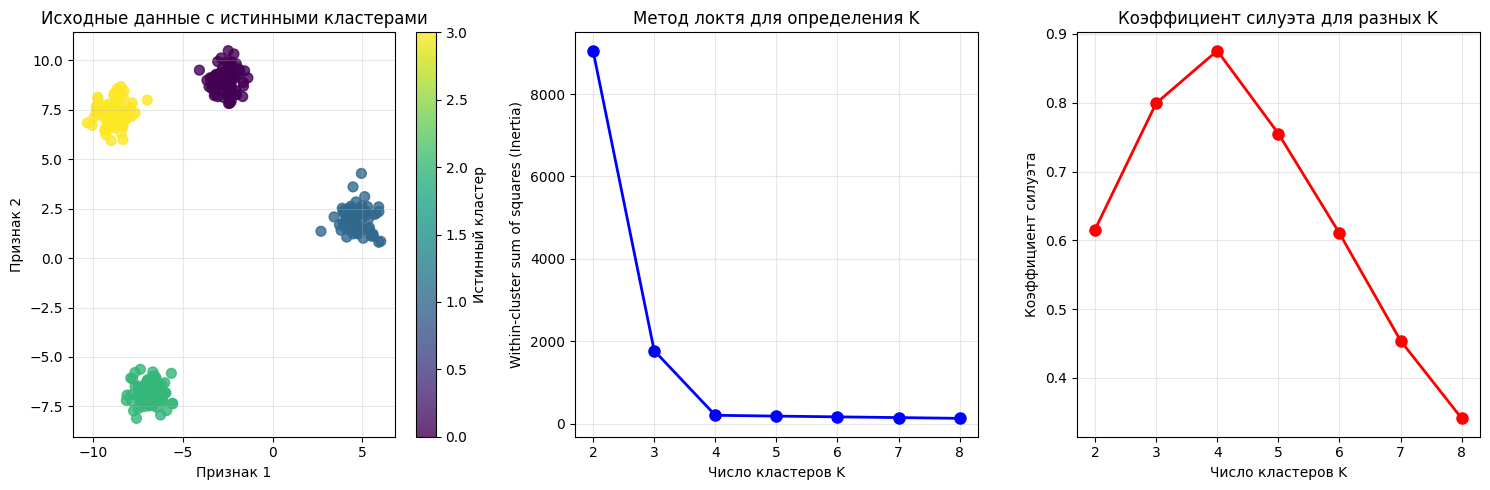


Оптимальное число кластеров: K=4


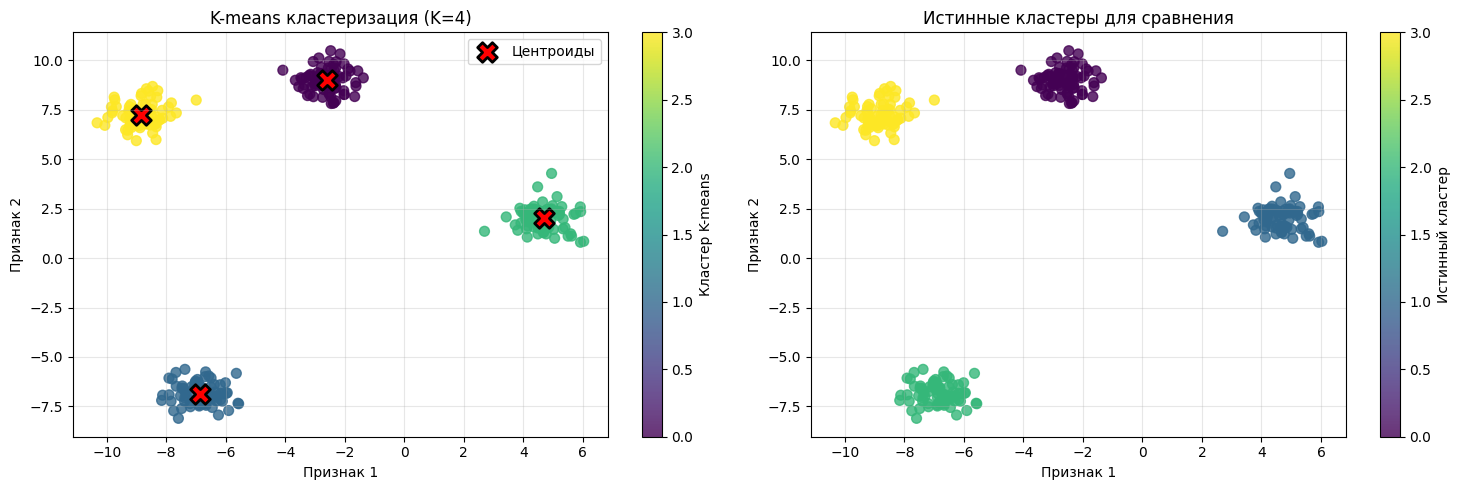

Коэффициент силуэта для K-means: 0.876

ПРИМЕНЕНИЕ МЕТОДА DBSCAN
Экспериментируем с параметрами DBSCAN:
eps=0.3, min_samples=3: кластеров=13, шум=43, силуэт=0.041
eps=0.3, min_samples=4: кластеров=7, шум=66, силуэт=0.315
eps=0.3, min_samples=5: кластеров=5, шум=85, силуэт=0.339
eps=0.5, min_samples=3: кластеров=4, шум=7, силуэт=0.828
eps=0.5, min_samples=4: кластеров=5, шум=8, силуэт=0.675
eps=0.5, min_samples=5: кластеров=4, шум=13, силуэт=0.798
eps=0.7, min_samples=3: кластеров=4, шум=4, силуэт=0.834
eps=0.7, min_samples=4: кластеров=4, шум=4, силуэт=0.834
eps=0.7, min_samples=5: кластеров=4, шум=4, силуэт=0.834
eps=1.0, min_samples=3: кластеров=4, шум=1, силуэт=0.773
eps=1.0, min_samples=4: кластеров=4, шум=1, силуэт=0.773
eps=1.0, min_samples=5: кластеров=4, шум=1, силуэт=0.773

Лучшие параметры: eps=0.7, min_samples=3
DBSCAN нашел 4 кластеров и 4 шумовых точек


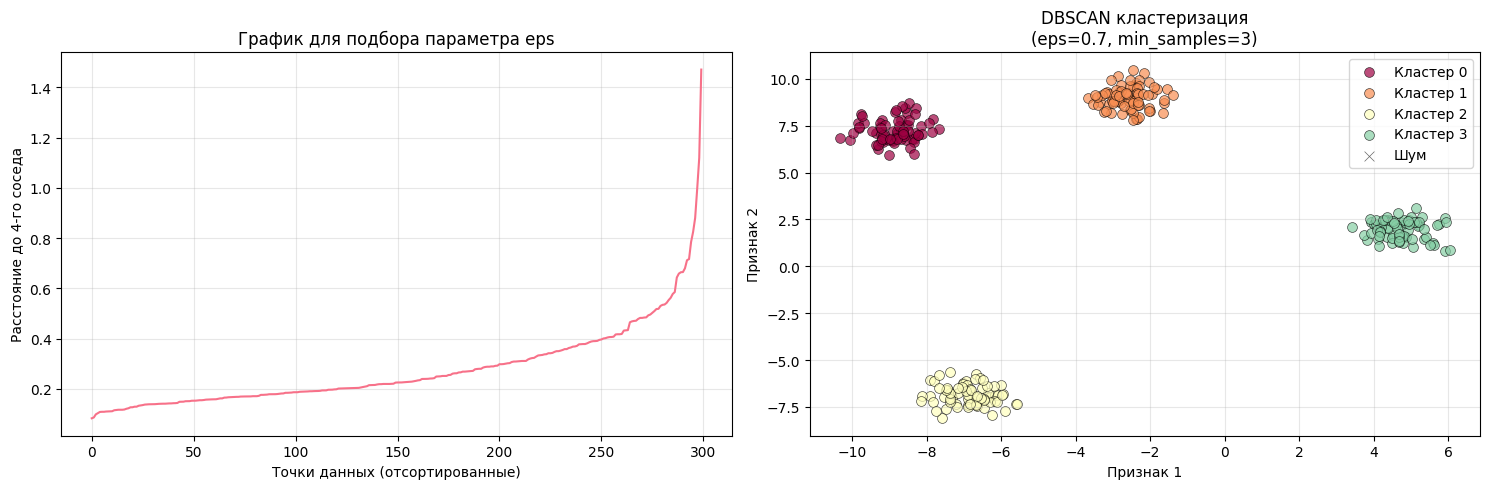


СРАВНЕНИЕ И АНАЛИЗ РЕЗУЛЬТАТОВ

СВОДКА РЕЗУЛЬТАТОВ:
Метод           Кластеров  Шум      Силуэт  
---------------------------------------------
Истинные        4          0        -       
K-means         4          0        0.876
DBSCAN          4          4        0.834


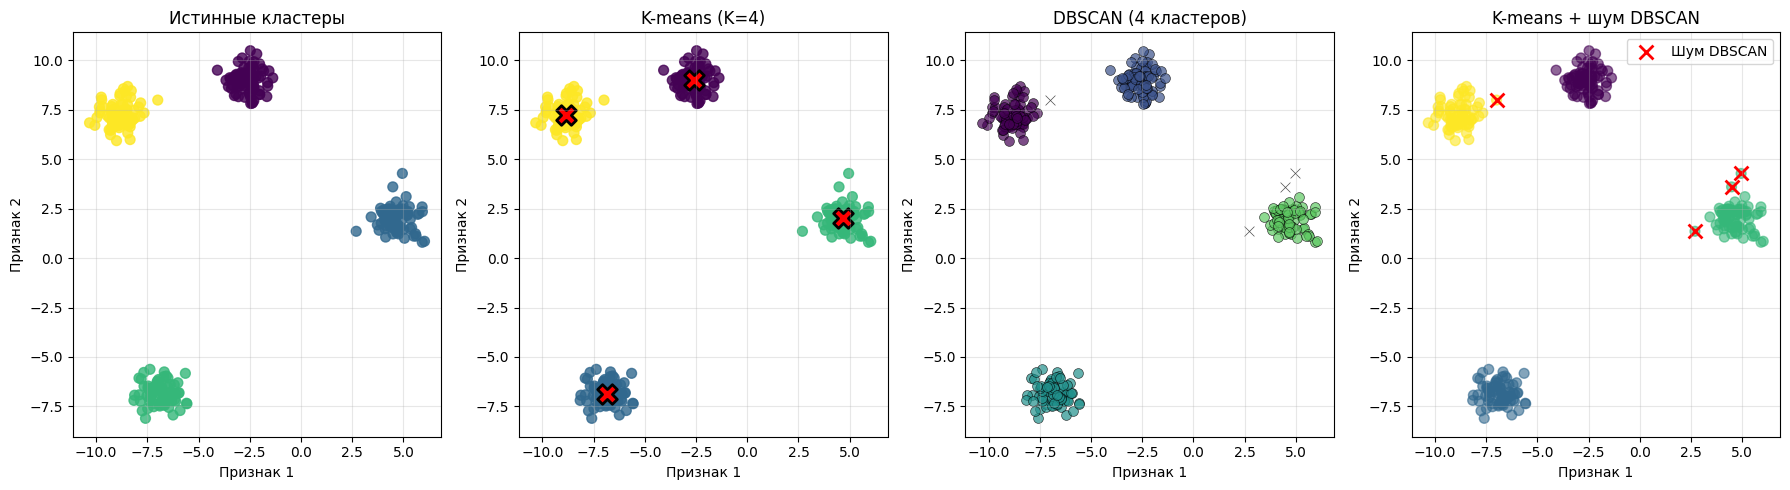

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.style.use('default')
sns.set_palette("husl")

print("КЛАСТЕРИЗАЦИЯ НА СГЕНЕРИРОВАННЫХ ДАННЫХ \n")

print("СОЗДАНИЕ НАБОРА ДАННЫХ")

X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60,
                       random_state=42, center_box=(-10, 10))

print(f"Размерность данных: {X.shape}")
print(f"Количество истинных кластеров: {len(np.unique(y_true))}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.8)
plt.title('Исходные данные с истинными кластерами')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.colorbar(label='Истинный кластер')
plt.grid(True, alpha=0.3)

print("\nПРИМЕНЕНИЕ МЕТОДА K-MEANS")

print("Подбор оптимального числа кластеров...")
inertia = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

    silhouette_avg = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)
    print(f"K={k}: inertia={inertia[-1]:.2f}, silhouette={silhouette_avg:.3f}")

plt.subplot(1, 3, 2)
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число кластеров K')
plt.ylabel('Within-cluster sum of squares (Inertia)')
plt.title('Метод локтя для определения K')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Число кластеров K')
plt.ylabel('Коэффициент силуэта')
plt.title('Коэффициент силуэта для разных K')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров: K={optimal_k}")

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans = kmeans_optimal.fit_predict(X)
centroids = kmeans_optimal.cluster_centers_

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50, alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200,
           label='Центроиды', edgecolors='black', linewidth=2)
plt.title(f'K-means кластеризация (K={optimal_k})')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.colorbar(scatter, label='Кластер K-means')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.8)
plt.title('Истинные кластеры для сравнения')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.colorbar(label='Истинный кластер')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

kmeans_silhouette = silhouette_score(X, y_kmeans)
print(f"Коэффициент силуэта для K-means: {kmeans_silhouette:.3f}")

print("\nПРИМЕНЕНИЕ МЕТОДА DBSCAN")

def find_optimal_eps(X, k):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X)
    distances, indices = neighbors_fit.kneighbors(X)
    distances = np.sort(distances[:, k-1], axis=0)
    return distances

k_min_samples = 4  # min_samples обычно = 2 * размерность данных
distances = find_optimal_eps(X, k_min_samples)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(distances)
plt.xlabel('Точки данных (отсортированные)')
plt.ylabel(f'Расстояние до {k_min_samples}-го соседа')
plt.title('График для подбора параметра eps')
plt.grid(True, alpha=0.3)


eps_candidates = [0.3, 0.5, 0.7, 1.0]
min_samples_candidates = [3, 4, 5]

print("Экспериментируем с параметрами DBSCAN:")

best_dbscan = None
best_silhouette = -1
best_params = {}

for eps in eps_candidates:
    for min_samples in min_samples_candidates:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        y_dbscan = dbscan.fit_predict(X)

        n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
        n_noise = list(y_dbscan).count(-1)

        if n_clusters > 1:
            silhouette_avg = silhouette_score(X, y_dbscan)
        else:
            silhouette_avg = -1

        print(f"eps={eps:.1f}, min_samples={min_samples}: "
              f"кластеров={n_clusters}, шум={n_noise}, силуэт={silhouette_avg:.3f}")

        if silhouette_avg > best_silhouette and n_clusters >= 2:
            best_silhouette = silhouette_avg
            best_dbscan = dbscan
            best_params = {'eps': eps, 'min_samples': min_samples}

print(f"\nЛучшие параметры: eps={best_params['eps']}, min_samples={best_params['min_samples']}")
dbscan_optimal = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
y_dbscan = dbscan_optimal.fit_predict(X)

unique_labels = set(y_dbscan)
n_clusters = len(unique_labels) - (1 if -1 in y_dbscan else 0)
n_noise = list(y_dbscan).count(-1)

print(f"DBSCAN нашел {n_clusters} кластеров и {n_noise} шумовых точек")

plt.subplot(1, 2, 2)

core_samples_mask = np.zeros_like(y_dbscan, dtype=bool)
core_samples_mask[dbscan_optimal.core_sample_indices_] = True

colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Шумовые точки
        col = 'black'
        marker = 'x'
        label = 'Шум'
        alpha = 0.6
    else:
        marker = 'o'
        label = f'Кластер {k}'
        alpha = 0.7

    class_member_mask = (y_dbscan == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=50,
               label=label, alpha=alpha, edgecolors='black' if k != -1 else None,
               linewidth=0.5)

plt.title(f'DBSCAN кластеризация\n(eps={best_params["eps"]}, min_samples={best_params["min_samples"]})')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nСРАВНЕНИЕ И АНАЛИЗ РЕЗУЛЬТАТОВ")

print("\nСВОДКА РЕЗУЛЬТАТОВ:")
print(f"{'Метод':<15} {'Кластеров':<10} {'Шум':<8} {'Силуэт':<8}")
print("-" * 45)
print(f"{'Истинные':<15} {len(np.unique(y_true)):<10} {'0':<8} {'-':<8}")
print(f"{'K-means':<15} {optimal_k:<10} {'0':<8} {kmeans_silhouette:.3f}")
print(f"{'DBSCAN':<15} {n_clusters:<10} {n_noise:<8} {best_silhouette:.3f}")

plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.8)
plt.title('Истинные кластеры')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha=0.3)

# K-means
plt.subplot(1, 4, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50, alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200,
           edgecolors='black', linewidth=2)
plt.title(f'K-means (K={optimal_k})')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha=0.3)

# DBSCAN
plt.subplot(1, 4, 3)
for k in unique_labels:
    if k == -1:
        col = 'black'
        marker = 'x'
    else:
        col = plt.cm.viridis(k / max(1, len(unique_labels)-1))
        marker = 'o'

    class_member_mask = (y_dbscan == k)
    xy = X[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=50,
               alpha=0.7, edgecolors='black' if k != -1 else None, linewidth=0.5)

plt.title(f'DBSCAN ({n_clusters} кластеров)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 4)
comparison_scatter = plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis',
                                s=50, alpha=0.6)
plt.scatter(X[y_dbscan == -1, 0], X[y_dbscan == -1, 1],
           c='red', marker='x', s=100, linewidth=2, label='Шум DBSCAN')
plt.title('K-means + шум DBSCAN')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
url =